<img src="./assets/ga-logo.png" style="float: left; margin: 20px; height: 55px">

# Lab: Simple Linear Regression with Sacramento Real Estate Data

---

In this lab you will hone your exploratory data analysis (EDA) skills and practice constructing linear regressions on a data set of Sacramento real estate sales.  The data set contains information on qualities of the property, location of the property, and time of sale.

### 1. Read in the Sacramento housing data set.

The file is stored in the `data` subfolder.

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler


In [1]:
import pandas as pd

df = pd.read_csv('sacramento_real_estate_transactions.csv')
df.head(5)

,street,city,zip,state,beds,baths,sq__ft,type,sale_date,price,latitude,longitude
0,3526 HIGH ST,SACRAMENTO,95838,CA,2,1,836,Residential,Wed May 21 00:00:00 EDT 2008,59222,38.631913,-121.434879
1,51 OMAHA CT,SACRAMENTO,95823,CA,3,1,1167,Residential,Wed May 21 00:00:00 EDT 2008,68212,38.478902,-121.431028
2,2796 BRANCH ST,SACRAMENTO,95815,CA,2,1,796,Residential,Wed May 21 00:00:00 EDT 2008,68880,38.618305,-121.443839
3,2805 JANETTE WAY,SACRAMENTO,95815,CA,2,1,852,Residential,Wed May 21 00:00:00 EDT 2008,69307,38.616835,-121.439146
4,6001 MCMAHON DR,SACRAMENTO,95824,CA,2,1,797,Residential,Wed May 21 00:00:00 EDT 2008,81900,38.519470,-121.435768


### 2. Conduct exploratory data analysis on this data set. 

If you discover any issues with the data, fix them to the best of your ability. Report any notable findings.

_**Note:** Zip codes often have leading zeros — e.g., 02215 = Boston, MA — which will often get knocked off automatically by many software programs like Python or Excel._

In [3]:
df.sq__ft.value_counts(ascending=False)

sq__ft
0       171
1120      8
795       6
1039      5
1080      5
       ... 
3192      1
3746      1
2607      1
2016      1
1319      1
Name: count, Length: 604, dtype: int64

In [4]:
df = df[df["sq__ft"] > 0]

In [5]:
df["zip"] = df["zip"].astype(str).str.zfill(5)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 813 entries, 0 to 984
Data columns (total 12 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   street     813 non-null    object 
 1   city       813 non-null    object 
 2   zip        813 non-null    object 
 3   state      813 non-null    object 
 4   beds       813 non-null    int64  
 5   baths      813 non-null    int64  
 6   sq__ft     813 non-null    int64  
 7   type       813 non-null    object 
 8   sale_date  813 non-null    object 
 9   price      813 non-null    int64  
 10  latitude   813 non-null    float64
 11  longitude  813 non-null    float64
dtypes: float64(2), int64(4), object(6)
memory usage: 82.6+ KB


In [7]:
df.describe()

,beds,baths,sq__ft,price,latitude,longitude
count,813.000000,813.000000,813.000000,813.000000,813.000000,813.000000
mean,3.247232,1.961870,1591.892989,229471.130381,38.576931,-121.378533
std,0.849012,0.669367,663.908347,119897.576889,0.126352,0.119730
min,1.000000,1.000000,484.000000,2000.000000,38.241514,-121.550527
25%,3.000000,2.000000,1144.000000,148750.000000,38.473814,-121.451444
50%,3.000000,2.000000,1419.000000,207973.000000,38.591618,-121.404999
75%,4.000000,2.000000,1851.000000,285000.000000,38.674864,-121.325730
max,8.000000,5.000000,5822.000000,884790.000000,39.008159,-120.597599


In [8]:
df.duplicated().sum()

np.int64(2)

In [9]:
df.drop_duplicates(inplace=True)

In [10]:
df.duplicated().sum()

np.int64(0)

Error in callback <function _draw_all_if_interactive at 0x000002674CB384A0> (for post_execute), with arguments args (),kwargs {}:


MemoryError: bad allocation

<Figure size 40000x10000 with 0 Axes>

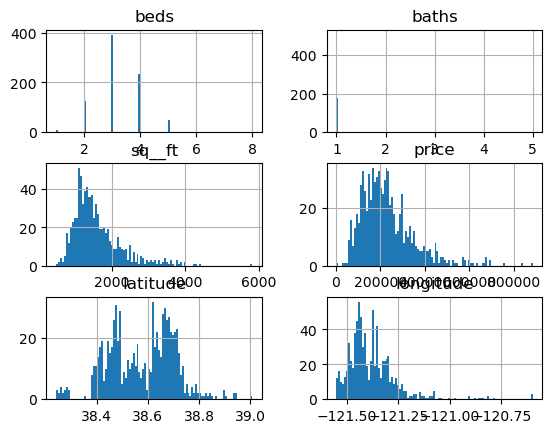

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(400, 100))
df.hist(bins=100);

In [12]:
df=df[(df['city']=="SACRAMENTO") & (df['state']=='CA')]
df

,street,city,zip,state,beds,baths,sq__ft,type,sale_date,price,latitude,longitude
0,3526 HIGH ST,SACRAMENTO,95838,CA,2,1,836,Residential,Wed May 21 00:00:00 EDT 2008,59222,38.631913,-121.434879
1,51 OMAHA CT,SACRAMENTO,95823,CA,3,1,1167,Residential,Wed May 21 00:00:00 EDT 2008,68212,38.478902,-121.431028
2,2796 BRANCH ST,SACRAMENTO,95815,CA,2,1,796,Residential,Wed May 21 00:00:00 EDT 2008,68880,38.618305,-121.443839
3,2805 JANETTE WAY,SACRAMENTO,95815,CA,2,1,852,Residential,Wed May 21 00:00:00 EDT 2008,69307,38.616835,-121.439146
4,6001 MCMAHON DR,SACRAMENTO,95824,CA,2,1,797,Residential,Wed May 21 00:00:00 EDT 2008,81900,38.519470,-121.435768
...,...,...,...,...,...,...,...,...,...,...,...,...
971,3528 SAINT GEORGE DR,SACRAMENTO,95821,CA,3,1,1040,Residential,Thu May 15 00:00:00 EDT 2008,224000,38.629468,-121.376445
977,5 BISHOPGATE CT,SACRAMENTO,95823,CA,4,2,1329,Residential,Thu May 15 00:00:00 EDT 2008,229500,38.467936,-121.445477
978,5601 REXLEIGH DR,SACRAMENTO,95823,CA,4,2,1715,Residential,Thu May 15 00:00:00 EDT 2008,230000,38.445342,-121.441504
980,9169 GARLINGTON CT,SACRAMENTO,95829,CA,4,3,2280,Residential,Thu May 15 00:00:00 EDT 2008,232425,38.457679,-121.359620


In [13]:
df.type.value_counts()

type
Residential     388
Condo            24
Multi-Family     10
Name: count, dtype: int64

In [14]:
df.city.value_counts()

city
SACRAMENTO    422
Name: count, dtype: int64

In [15]:
df = df.drop(columns=['city','state'])
df

,street,zip,beds,baths,sq__ft,type,sale_date,price,latitude,longitude
0,3526 HIGH ST,95838,2,1,836,Residential,Wed May 21 00:00:00 EDT 2008,59222,38.631913,-121.434879
1,51 OMAHA CT,95823,3,1,1167,Residential,Wed May 21 00:00:00 EDT 2008,68212,38.478902,-121.431028
2,2796 BRANCH ST,95815,2,1,796,Residential,Wed May 21 00:00:00 EDT 2008,68880,38.618305,-121.443839
3,2805 JANETTE WAY,95815,2,1,852,Residential,Wed May 21 00:00:00 EDT 2008,69307,38.616835,-121.439146
4,6001 MCMAHON DR,95824,2,1,797,Residential,Wed May 21 00:00:00 EDT 2008,81900,38.519470,-121.435768
...,...,...,...,...,...,...,...,...,...,...
971,3528 SAINT GEORGE DR,95821,3,1,1040,Residential,Thu May 15 00:00:00 EDT 2008,224000,38.629468,-121.376445
977,5 BISHOPGATE CT,95823,4,2,1329,Residential,Thu May 15 00:00:00 EDT 2008,229500,38.467936,-121.445477
978,5601 REXLEIGH DR,95823,4,2,1715,Residential,Thu May 15 00:00:00 EDT 2008,230000,38.445342,-121.441504
980,9169 GARLINGTON CT,95829,4,3,2280,Residential,Thu May 15 00:00:00 EDT 2008,232425,38.457679,-121.359620


In [16]:
df = df.drop(columns=["street", "sale_date"])
df

,zip,beds,baths,sq__ft,type,price,latitude,longitude
0,95838,2,1,836,Residential,59222,38.631913,-121.434879
1,95823,3,1,1167,Residential,68212,38.478902,-121.431028
2,95815,2,1,796,Residential,68880,38.618305,-121.443839
3,95815,2,1,852,Residential,69307,38.616835,-121.439146
4,95824,2,1,797,Residential,81900,38.519470,-121.435768
...,...,...,...,...,...,...,...,...
971,95821,3,1,1040,Residential,224000,38.629468,-121.376445
977,95823,4,2,1329,Residential,229500,38.467936,-121.445477
978,95823,4,2,1715,Residential,230000,38.445342,-121.441504
980,95829,4,3,2280,Residential,232425,38.457679,-121.359620


In [17]:
df.type.value_counts()

type
Residential     388
Condo            24
Multi-Family     10
Name: count, dtype: int64

When you've finished cleaning or have made a good deal of progress cleaning, it's always a good idea to save your work. Use the pandas `to_csv` method to export your cleaned dataset.

```python
# example -- your dataframe name may be different
dataframe.to_csv('./datasets/sacramento_cleaned_dataframe.csv', index=False)

```

### 3. Our goal will be to predict price. List variables that you think qualify as predictors of price in an SLR model.

For each of the variables you believe should be considered, generate a plot showing the relationship between the independent and dependent variables.

In [18]:
df.columns

Index(['zip', 'beds', 'baths', 'sq__ft', 'type', 'price', 'latitude',
       'longitude'],
      dtype='object')

In [19]:
df.head(1)

,zip,beds,baths,sq__ft,type,price,latitude,longitude
0,95838,2,1,836,Residential,59222,38.631913,-121.434879


In [20]:
num_df=df.drop(columns=['latitude','longitude'])

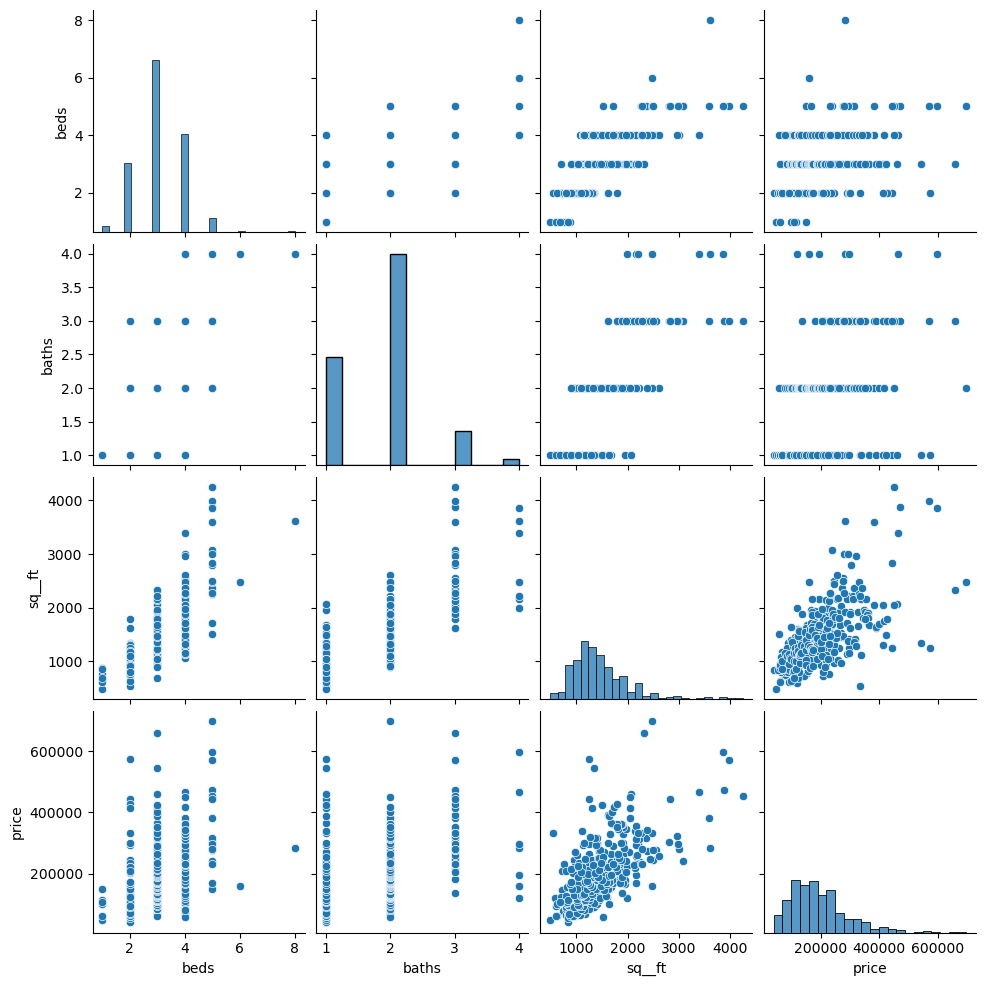

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.pairplot(num_df)

In [23]:
corr_table = df.drop(columns=['type','latitude','longitude']).corr()
corr_table

,zip,beds,baths,sq__ft,price
zip,1.000000,0.110964,0.169288,0.175485,0.095220
beds,0.110964,1.000000,0.654037,0.736422,0.378121
baths,0.169288,0.654037,1.000000,0.736452,0.406250
sq__ft,0.175485,0.736422,0.736452,1.000000,0.651141
price,0.095220,0.378121,0.406250,0.651141,1.000000


### 4. Which variable would be the best predictor of Y in an SLR model? Why?

In [22]:
# sq__ft as it has the highest correlation with price

### 5. Write a function that will take in two lists, `x` and `y`, and return the intercept and slope coefficients that minimize SSE. 

`y` is the target variable, and `x` is the predictor variable.

**Don't use `scikit-learn` for this**. Instead, use `numpy` and `scipy`.

The slope and intercept of simple linear regression can be calculated by using certain summary statistics. In particular, we'll need to know:

- $\bar{x}$, the mean of `x`
- $\bar{y}$, the mean of `y`
- $s_{x}$, the standard deviation of `x`
- $s_{y}$, the standard deviation of `y`
- $r_{xy}$, the correlation of `x` and `y`

Given these summary statistics, the **coefficient on `X`** (or the slope) can be given by $\beta_{1} = r_{xy} * \frac{s_{y}}{s_{x}}$. The **intercept of the model** can be given by $\beta_{0} = \bar{y} - \beta_{1}\bar{x}$.

Your function should take in `x` and `y`, then use the above summary statistics to calculate the slope and intercept.

- **Test your function on price and the variable you determined was the best predictor in Problem 4.**
- **Report the slope and intercept.**

In [31]:
import numpy as np

def SSE_alternative1(x, y):
    x = np.array(x)
    y = np.array(y)
    covariance = np.cov(x, y, ddof=1)[0, 1]
    variance_x = np.var(x, ddof=1)
    slope= covariance / variance_x
    intercept= np.mean(y) - slope * np.mean(x)
    
    return intercept, slope
    
intercept, slope = SSE_alternative1(num_df['baths'], num_df['price'])
print('intercept:', intercept, 'slope:', slope)

intercept: 81517.93955379997 slope: 62015.991580150985


### 6. Interpret the intercept and the slope.

In [126]:
intercept = 81517.93955379997  # Predicted price when number of bathrooms is 0
slope = 62015.991580150985    # Price increases by ~$62,016 for each additional bathroom

---

## Dummy Variables

It is important to be cautious with categorical variables, which represent distict groups or categories, when building a regression. If put in a regression "as-is," categorical variables represented as integers will be treated like *continuous* variables.

That is to say, instead of group "3" having a different effect on the estimation than group "1" it will estimate literally 3 times more than group 1. 

For example, if occupation category "1" represents "analyst" and occupation category "3" represents "barista", and our target variable is salary, if we leave this as a column of integers then barista will always have `beta*3` the effect of analyst.

This will almost certainly force the beta coefficient to be something strange and incorrect. Instead, we can re-represent the categories as multiple "dummy coded" columns.



#### A Word of Caution When Creating Dummies

Let's touch on precautions we should take when dummy coding.

**If you convert a qualitative variable to dummy variables, you want to turn a variable with N categories into N-1 variables.**

> **Scenario 1:** Suppose we're working with the variable "sex" or "gender" with values "M" and "F". 

You should include in your model only one variable for "sex = F" which takes on 1 if sex is female and 0 if sex is not female! Rather than saying "a one unit change in X," the coefficient associated with "sex = F" is interpreted as the average change in Y when sex = F relative to when sex = M.

| Female | Male | 
|-------|------|
| 0 | 1 | 
| 1 | 0 |
| 0 | 1 |
| 1 | 0 |
| 1 | 0 |
_As we can see a 1 in the female column indicates a 0 in the male column. And so, we have two columns stating the same information in different ways._

> Scenario 2: Suppose we're modeling revenue at a bar for each of the days of the week. We have a column with strings identifying which day of the week this observation occured in.

We might include six of the days as their own variables: "Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday". **But not all 7 days.**  

|Monday | Tuesday | Wednesday | Thursday | Friday | Saturday | 
|-------|---------|-----------|----------|--------|----------|
| 1     | 0       |0          |      0   |0       | 0        | 
| 0     | 1       |0          |      0   |0       | 0        | 
| 0     | 0       |1          |      0   |0       | 0        | 
| 0     | 0       |0          |      1   |0       | 0        | 
| 0     | 0       |0          |      0   |1       | 0        | 
| 0     | 0       |0          |      0   |0       | 1        | 
| 0     | 0       |0          |      0   |0       | 0        | 

_As humans we can infer from the last row that if its is not Monday, Tuesday, Wednesday, Thursday, Friday or Saturday, it must be Sunday. Models work the same way._

The coefficient for Monday is then interpreted as the average change in revenue when "day = Monday" relative to "day = Sunday." The coefficient for Tuesday is interpreted as the average change in revenue when "day = Tuesday" relative to "day = Sunday" and so on.

The category you leave out, which the other columns are *relative to*, is often referred to as the **reference category**.

### 7. Use the `OneHotEncoder` to convert the `type` column into dummy-coded variables.

In [25]:
#I removed type from the beginning as I found out that it is not necessary aspect, however I will add it again in num_df for the sake of answering this question
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

encoder = OneHotEncoder(drop='first', sparse_output=False)
type_dummies = encoder.fit_transform(num_df[['type']])
feature_names = encoder.get_feature_names_out(['type'])
type_dummies_df = pd.DataFrame(type_dummies, columns=feature_names, index=num_df.index)
type_dummies_df

,type_Multi-Family,type_Residential
0,0.0,1.0
1,0.0,1.0
2,0.0,1.0
3,0.0,1.0
4,0.0,1.0
...,...,...
971,0.0,1.0
977,0.0,1.0
978,0.0,1.0
980,0.0,1.0


### 8. Check the dummy columns you've created. Do they all make sense?

Use `.head()` on the new dataframe you've created. Depending on how you cleaned the data earlier in this notebook, there may be a dummy column that needs to be removed. Check that all the columns you've created make sense, and if any of the columns seem to be errors, drop them. If there don't appear to be any errors, then move on to the next step!

In [26]:
type_dummies = pd.get_dummies(df['type'], drop_first=True, prefix='type')
type_dummies.head()

,type_Multi-Family,type_Residential
0,False,True
1,False,True
2,False,True
3,False,True
4,False,True


### 9. Build what you think may be the best MLR model predicting `price`. 

Choose at least three variables, and build a model that uses them to predict price. At least one of the variables you choose should be a dummy-coded variable. (This can be one we created before or a new one.) 

You may need to load in the scikit-learn API:

```python
from sklearn.linear_model import LinearRegression

model = LinearRegression()
```

In [37]:
from sklearn.linear_model import LinearRegression

type_dummies = pd.get_dummies(df['type'], drop_first=True, prefix='type')
X_train = pd.concat([num_df[['sq__ft', 'beds', 'baths']], type_dummies], axis=1)
y_train = num_df[['price']]
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [38]:
model.coef_

array([[   160.07159334, -25319.85633536, -15149.63934844,
          -718.58588756,  35724.08847592]])

In [39]:
model.intercept_

array([37748.8869069])

### 10. Plot the true price vs the predicted price to evaluate your MLR visually.

You can use matplotlib or seaborn.

Text(0.5, 1.0, 'True Price vs Predicted Price')

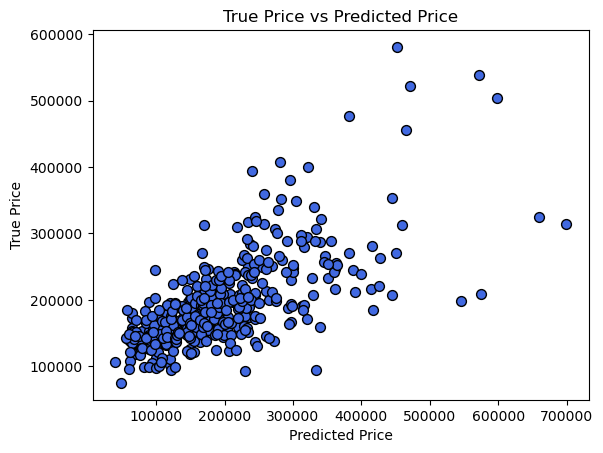

In [46]:
import matplotlib.pyplot as plt

y_pred = model.predict(X_train)
plt.scatter(y_train, y_pred, color='royalblue', edgecolor='k', s=50)
plt.xlabel('Predicted Price')
plt.ylabel('True Price')
plt.title('True Price vs Predicted Price')


### 11. Metrics, metrics, everywhere...

Calculate and interpret at least three regression metrics. How well does your model perform?

In [48]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,root_mean_squared_error
print(mean_absolute_error(y_train,y_pred))
print(mean_squared_error(y_train,y_pred))
print(root_mean_squared_error(y_train,y_pred))

53343.52678595396
5427277375.10305
73670.05752069867
